# Import Libraries

In [332]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pl


## Load Dataset

In [333]:
df = pd.read_csv('cars.csv')

df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## Data Understanding

In [334]:
cdf = df[['brand' , 'model_year' , 'milage' , 'fuel_type' , 'transmission' , 'price']]

cdf.head(9)

,brand,model_year,milage,fuel_type,transmission,price
0,Ford,2013,"51,000 mi.",E85 Flex Fuel,6-Speed A/T,"$10,300"
1,Hyundai,2021,"34,742 mi.",Gasoline,8-Speed Automatic,"$38,005"
2,Lexus,2022,"22,372 mi.",Gasoline,Automatic,"$54,598"
3,INFINITI,2015,"88,900 mi.",Hybrid,7-Speed A/T,"$15,500"
4,Audi,2021,"9,835 mi.",Gasoline,8-Speed Automatic,"$34,999"
5,Acura,2016,"136,397 mi.",Gasoline,F,"$14,798"
6,Audi,2017,"84,000 mi.",Gasoline,6-Speed A/T,"$31,000"
7,BMW,2001,"242,000 mi.",Gasoline,A/T,"$7,300"
8,Lexus,2021,"23,436 mi.",Gasoline,6-Speed A/T,"$41,927"


## Data Cleaning

In [335]:
df['milage'] = df['milage'].str.replace(',' , '').str.replace('mi.' , '').astype(float)

df['price'] = df['price'].str.replace('$' , '').str.replace(',' , '').astype(float)


df = df[df["price"] <= 200000].copy()
des_price = cdf['price'].describe()
des_milage = cdf['milage'].describe()

# For model

print(des_price)
print(des_milage)

count        4009
unique       1569
top       $15,000
freq           39
Name: price, dtype: object
count            4009
unique           2818
top       110,000 mi.
freq               16
Name: milage, dtype: object


## Exploratory Data Analysis

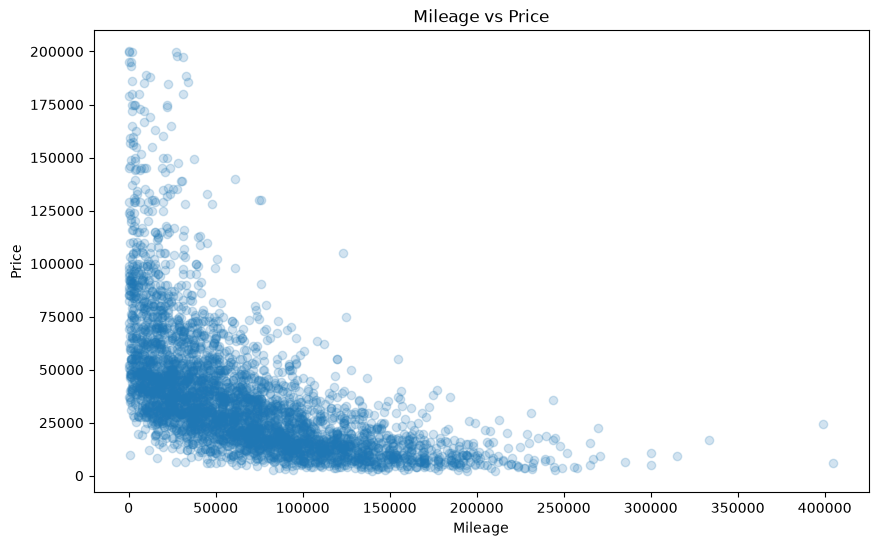

In [336]:
plt.figure(figsize=(10, 6))

plt.scatter(df.milage , df.price , alpha=0.2)

plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")

plt.show()

## Train & Test Split

In [337]:
msk = np.random.rand(len(df)) < 0.8
train = df[msk]
test = df[~msk]

## Training Model 

In [349]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn import linear_model

train_x = np.asanyarray(train[['milage']])
train_y = np.asanyarray(train[['price']])

test_x = np.asanyarray(test[['milage']])
test_y = np.asanyarray(test[['price']])

print(train_x[:3])

poly = PolynomialFeatures(degree = 2)

train_x_poly = poly.fit_transform(train_x)
train_x_poly

[[51000.]
 [34742.]
 [22372.]]


array([[1.00000000e+00, 5.10000000e+04, 2.60100000e+09],
       [1.00000000e+00, 3.47420000e+04, 1.20700656e+09],
       [1.00000000e+00, 2.23720000e+04, 5.00506384e+08],
       ...,
       [1.00000000e+00, 5.37050000e+04, 2.88422702e+09],
       [1.00000000e+00, 3.30000000e+04, 1.08900000e+09],
       [1.00000000e+00, 4.30000000e+04, 1.84900000e+09]], shape=(3144, 3))

## Coefficients & Intercept

In [350]:
clf = linear_model.LinearRegression()
train_y_ = clf.fit(train_x_poly , train_y)

print('Coefficients :' , clf.coef_)
print('Intercept :' , clf.intercept_)

Coefficients : [[ 0.00000000e+00 -7.01755750e-01  1.94836479e-06]]
Intercept : [70414.31932679]


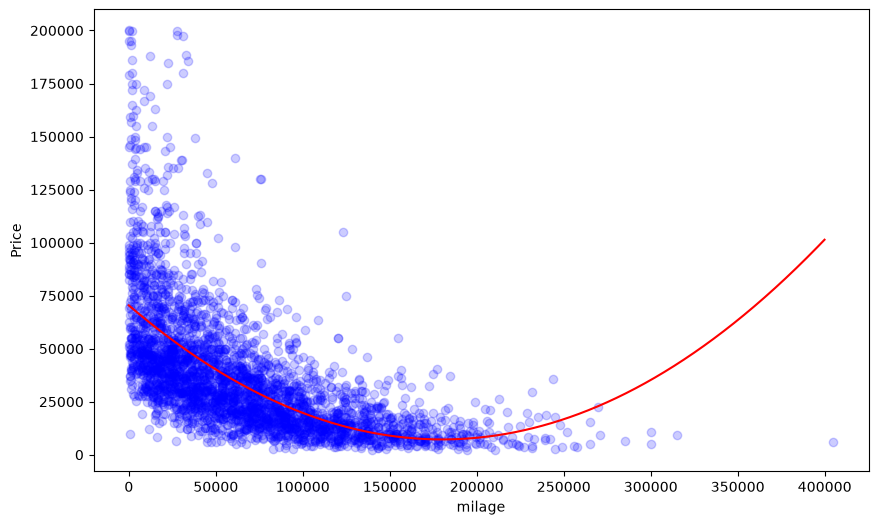

In [351]:
plt.figure(figsize = (10 , 6))

plt.scatter(train.milage , train.price , color = 'blue' , alpha = 0.2)

XX = np.arange(0 , 400000 , 100)
YY = clf.intercept_[0] + clf.coef_[0][1] * train.milage + clf.coef_[0][2] * np.power(train.milage , 2)

plt.plot(XX , YY , 'r-')
plt.ylabel('Price')
plt.xlabel('milage')

plt.show()